In [17]:
import os
import pickle
import sys
from itertools import combinations

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_DISPLAY_NAMES

In [18]:
project_root = '../../../..'
overlap_criteria = 1
N_PERMUTATIONS = 1000  # increase for more precise p-values near the boundary
PERMUTATION_SEED = 42

read_lengths = [75, 100, 150, 300]
all_models = [
    'fgs_complete', 'prodigal',
    'deep_cds_a2',  # DeepCDS codon-only (A2)
    'deep_cds_a1',  # DeepCDS pLM-only (A1)
    'deep_cds',     # DeepCDS full model
]

# Comparison 1: DeepCDS vs external baselines
baseline_models = ['fgs_complete', 'prodigal', 'deep_cds']
# Comparison 2: DeepCDS ablation models only
ablation_models = ['deep_cds_a2', 'deep_cds_a1', 'deep_cds']

TT4_FAMILIES = ['Mycoplasmataceae']

LOAD_PROCESSED_DATA = False
_cache_dir = f'{project_root}/data/processed_data/report_results/without_errors/statistical_significance_testing'
# Cache filename encodes the full model set; rename if models change to avoid stale loads.
_cache_file = os.path.join(_cache_dir, 'per_read_counts_all_ablations.pkl')

In [19]:
all_test_accessions = open(
    f'{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt'
).read().splitlines()

genome_info_df = pd.read_csv(
    f'{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv'
).set_index('accession')

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        tt = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {'translation_table': tt}

tt11_accessions = [acc for acc, info in all_genomes.items()
                   if info['translation_table'] == 11]
print(f'TT11 genomes (used for evaluation): {len(tt11_accessions)}')

TT11 genomes (used for evaluation): 212


In [20]:
def calculate_iou(coord1, coord2):
    s1, e1, rf1 = coord1
    s2, e2, rf2 = coord2
    if rf1 != rf2:
        return 0.0
    intersection = min(e1, e2) - max(s1, s2)
    if intersection <= 0:
        return 0.0
    union = max(e1, e2) - min(s1, s2)
    return intersection / union if union > 0 else 0.0


def find_matching_genes(predicted, actual, overlap_criteria):
    matched, used = [], set()
    for pi, pc in enumerate(predicted):
        best_iou, best_ai = 0.0, -1
        for ai, ac in enumerate(actual):
            if ai in used:
                continue
            iou = calculate_iou(pc, ac)
            if iou >= overlap_criteria and iou > best_iou:
                best_iou, best_ai = iou, ai
        if best_ai != -1:
            matched.append((pi, best_ai))
            used.add(best_ai)
    return matched, len(matched)


def calculate_per_read_counts(testset_dict, preds_dict, read_names, overlap_criteria):
    """Return (tp, fp, fn) counts for each read as a numpy array of shape (n_reads, 3).
    Iterates over ALL read_names so FP predictions on CDS-free reads are captured."""
    rows = []
    for rn in read_names:
        gt   = testset_dict.get(rn, {}).get('cds_coords', [])
        pred = preds_dict.get(rn, {}).get('cds_coords', [])
        _, tp = find_matching_genes(pred, gt, overlap_criteria)
        rows.append((tp, len(pred) - tp, len(gt) - tp))
    return np.array(rows, dtype=np.int16)


def load_testset(acc, data_type):
    base = f'{project_root}/data/processed_data/testset_processed/{data_type}/{acc}'
    with open(f'{base}/testset_dict.pkl', 'rb') as f:
        td = pickle.load(f)
    with open(f'{base}/read_names_list.pkl', 'rb') as f:
        rn = pickle.load(f)
    return rn, td


def load_preds(acc, data_type, model):
    base = f'{project_root}/data/processed_data/predictions/processed_predictions'
    paths = {
        'fgs_complete': f'{base}/fgs_preds/{data_type}/{acc}.pkl',
        'prodigal':     f'{base}/prodigal_preds/{data_type}/{acc}/model_preds_dict.pkl',
        'deep_cds_a2':  f'{base}/DeepCDS_codon_only/model_without_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{acc}/model_preds_dict.pkl',
        'deep_cds_a1':  f'{base}/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{acc}/model_preds_dict.pkl',
        'deep_cds':     f'{base}/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{acc}/model_preds_dict.pkl',
    }
    with open(paths[model], 'rb') as f:
        preds = pickle.load(f)
    return preds

In [21]:
# per_read_counts[length][accession][model] = np.array shape (n_reads, 3): columns are tp, fp, fn

if LOAD_PROCESSED_DATA and os.path.isfile(_cache_file):
    print(f'Loading from {_cache_file} ...')
    with open(_cache_file, 'rb') as f:
        per_read_counts = pickle.load(f)
else:
    per_read_counts = {length: {} for length in read_lengths}

    for length in read_lengths:
        data_type = f'without_errors_{length}bp'
        print(f'\nProcessing {data_type} ...')

        for acc in tqdm(tt11_accessions, desc=f'{length}bp'):
            try:
                read_names, testset = load_testset(acc, data_type)
            except Exception:
                continue

            per_read_counts[length][acc] = {}
            for model in all_models:
                try:
                    preds = load_preds(acc, data_type, model)
                    per_read_counts[length][acc][model] = calculate_per_read_counts(
                        testset, preds, read_names, overlap_criteria
                    )
                except Exception:
                    pass

    os.makedirs(_cache_dir, exist_ok=True)
    with open(_cache_file, 'wb') as f:
        pickle.dump(per_read_counts, f)
    print(f'\nSaved to {_cache_file}')

# Report total read counts per length
for length in read_lengths:
    n_accs = len(per_read_counts[length])
    n_reads_total = sum(
        v[next(iter(v))].shape[0]
        for v in per_read_counts[length].values() if v
    )
    print(f'{length}bp: {n_accs} genomes, ~{n_reads_total:,} total reads')


Processing without_errors_75bp ...


75bp: 100%|██████████| 212/212 [04:08<00:00,  1.17s/it]



Processing without_errors_100bp ...


100bp: 100%|██████████| 212/212 [03:15<00:00,  1.08it/s]



Processing without_errors_150bp ...


150bp: 100%|██████████| 212/212 [01:52<00:00,  1.89it/s]



Processing without_errors_300bp ...


300bp: 100%|██████████| 212/212 [00:46<00:00,  4.59it/s]



Saved to ../../../../data/processed_data/report_results/without_errors/statistical_significance_testing/per_read_counts_all_ablations.pkl
75bp: 212 genomes, ~20,593,443 total reads
100bp: 212 genomes, ~15,409,378 total reads
150bp: 212 genomes, ~10,227,129 total reads
300bp: 212 genomes, ~5,046,819 total reads


In [22]:
def f1_from_sums(s):
    tp, fp, fn = float(s[0]), float(s[1]), float(s[2])
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
    return 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0


def _f1_vec(sums):
    """Vectorized F1 for a (k, 3) array of [tp, fp, fn] column sums."""
    tp, fp, fn = sums[:, 0], sums[:, 1], sums[:, 2]
    prec = np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1e-9), 0.0)
    rec  = np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1e-9), 0.0)
    return np.where(prec + rec > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-9), 0.0)


def permutation_f1_pvalue(counts_a, counts_b, n_permutations, rng):
    """Paired permutation test for equality of aggregate F1 scores."""
    active = (counts_a.sum(axis=1) > 0) | (counts_b.sum(axis=1) > 0)
    ca = counts_a[active].astype(np.float32)
    cb = counts_b[active].astype(np.float32)
    n = len(ca)

    ca_sum = ca.sum(axis=0)
    cb_sum = cb.sum(axis=0)
    diff = cb - ca

    f1_a = f1_from_sums(ca_sum)
    f1_b = f1_from_sums(cb_sum)
    obs_diff = f1_a - f1_b

    chunk_size = max(5, min(200, 2_000_000 // max(n, 1)))

    perm_diffs = np.empty(n_permutations)
    pos = 0
    while pos < n_permutations:
        k = min(chunk_size, n_permutations - pos)
        S = rng.integers(0, 2, (k, n), dtype=np.uint8).astype(np.float32)
        Sd = S @ diff  # (k, 3) — BLAS SGEMM
        perm_diffs[pos:pos+k] = _f1_vec(ca_sum + Sd) - _f1_vec(cb_sum - Sd)
        pos += k

    p = float(np.mean(np.abs(perm_diffs) >= abs(obs_diff)))
    return f1_a, f1_b, obs_diff, max(p, 1.0 / n_permutations)


def run_permutation_pairwise(counts_by_acc, models, n_permutations, seed):
    """Run pairwise permutation F1 tests for all model pairs with Holm correction."""
    n = len(models)
    pairs = list(combinations(range(n), 2))
    rng = np.random.default_rng(seed)

    raw_ps, valid_pairs = [], []
    f1_cache = {}

    for i, j in tqdm(pairs, desc='pairs'):
        m_a, m_b = models[i], models[j]

        shared = [acc for acc in counts_by_acc
                  if m_a in counts_by_acc[acc] and m_b in counts_by_acc[acc]]
        if len(shared) < 5:
            continue

        ca = np.concatenate([counts_by_acc[acc][m_a] for acc in shared])
        cb = np.concatenate([counts_by_acc[acc][m_b] for acc in shared])

        f1_a, f1_b, _, p = permutation_f1_pvalue(ca, cb, n_permutations, rng)
        f1_cache[m_a] = f1_a
        f1_cache[m_b] = f1_b
        raw_ps.append(p)
        valid_pairs.append((i, j))

    p_holm = np.full((n, n), np.nan)
    if raw_ps:
        _, corrected, _, _ = multipletests(raw_ps, method='holm')
        for (i, j), p in zip(valid_pairs, corrected):
            p_holm[i, j] = p_holm[j, i] = p

    f1_obs = np.array([f1_cache.get(m, np.nan) for m in models])
    return p_holm, f1_obs


# --- Comparison 1: DeepCDS vs external baselines ---
print('=' * 60)
print('COMPARISON 1: DeepCDS vs FGS (Complete) vs MetaProdigal')
print('=' * 60)
permutation_results_baseline = {}
for length in read_lengths:
    print(f'\n=== {length}bp ===')
    models = [m for m in baseline_models if any(m in per_read_counts[length][acc]
                                                 for acc in per_read_counts[length])]
    p_mat, f1_obs = run_permutation_pairwise(
        per_read_counts[length], models, N_PERMUTATIONS, PERMUTATION_SEED
    )
    permutation_results_baseline[length] = {'models': models, 'p_matrix': p_mat, 'f1_obs': f1_obs}
    print('Observed F1 scores:')
    for m, f in zip(models, f1_obs):
        print(f'  {MODEL_DISPLAY_NAMES.get(m, m)}: {f:.4f}')

# --- Comparison 2: DeepCDS ablation models only ---
print('\n' + '=' * 60)
print('COMPARISON 2: DeepCDS ablation models')
print('=' * 60)
permutation_results_ablation = {}
for length in read_lengths:
    print(f'\n=== {length}bp ===')
    models = [m for m in ablation_models if any(m in per_read_counts[length][acc]
                                                 for acc in per_read_counts[length])]
    p_mat, f1_obs = run_permutation_pairwise(
        per_read_counts[length], models, N_PERMUTATIONS, PERMUTATION_SEED
    )
    permutation_results_ablation[length] = {'models': models, 'p_matrix': p_mat, 'f1_obs': f1_obs}
    print('Observed F1 scores:')
    for m, f in zip(models, f1_obs):
        print(f'  {MODEL_DISPLAY_NAMES.get(m, m)}: {f:.4f}')

COMPARISON 1: DeepCDS vs FGS (Complete) vs MetaProdigal

=== 75bp ===


pairs:   0%|          | 0/3 [00:00<?, ?it/s]/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_46318/2171637176.py:38: RuntimeWarning: divide by zero encountered in matmul
  Sd = S @ diff  # (k, 3) — BLAS SGEMM
/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_46318/2171637176.py:38: RuntimeWarning: overflow encountered in matmul
  Sd = S @ diff  # (k, 3) — BLAS SGEMM
/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_46318/2171637176.py:38: RuntimeWarning: invalid value encountered in matmul
  Sd = S @ diff  # (k, 3) — BLAS SGEMM
pairs: 100%|██████████| 3/3 [00:58<00:00, 19.54s/it]


Observed F1 scores:
  FGS (Complete): 0.8128
  MetaProdigal: 0.8194
  DeepCDS: 0.8762

=== 100bp ===


pairs: 100%|██████████| 3/3 [00:42<00:00, 14.29s/it]


Observed F1 scores:
  FGS (Complete): 0.8415
  MetaProdigal: 0.8548
  DeepCDS: 0.9195

=== 150bp ===


...

Observed F1 scores:
  DeepCDS (Codon): 0.9003
  DeepCDS (pLM): 0.8937
  DeepCDS: 0.9195

=== 150bp ===


pairs: 100%|██████████| 3/3 [00:25<00:00,  8.62s/it]


Observed F1 scores:
  DeepCDS (Codon): 0.9383
  DeepCDS (pLM): 0.9385
  DeepCDS: 0.9533

=== 300bp ===


pairs: 100%|██████████| 3/3 [00:13<00:00,  4.38s/it]

Observed F1 scores:
  DeepCDS (Codon): 0.9580
  DeepCDS (pLM): 0.9596
  DeepCDS: 0.9649


COMPARISON 1: DeepCDS vs external baselines


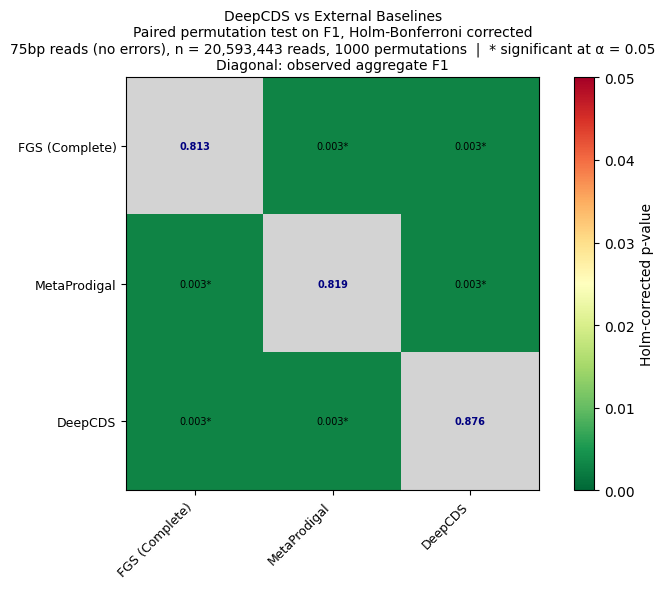

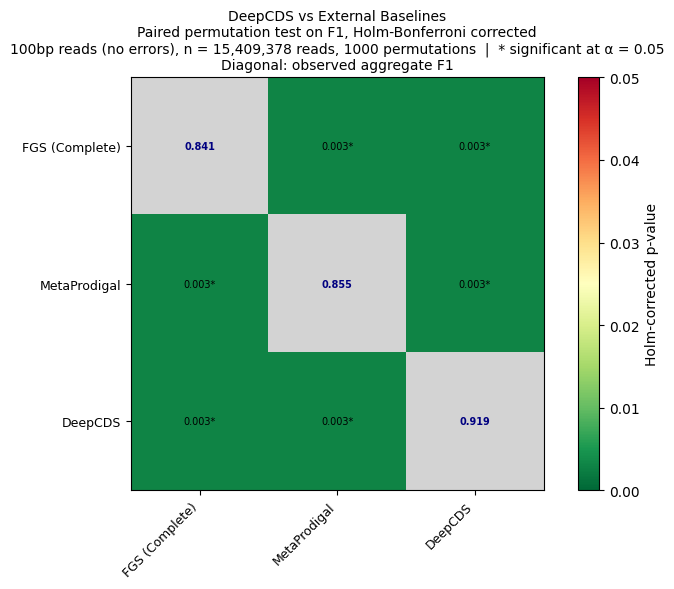

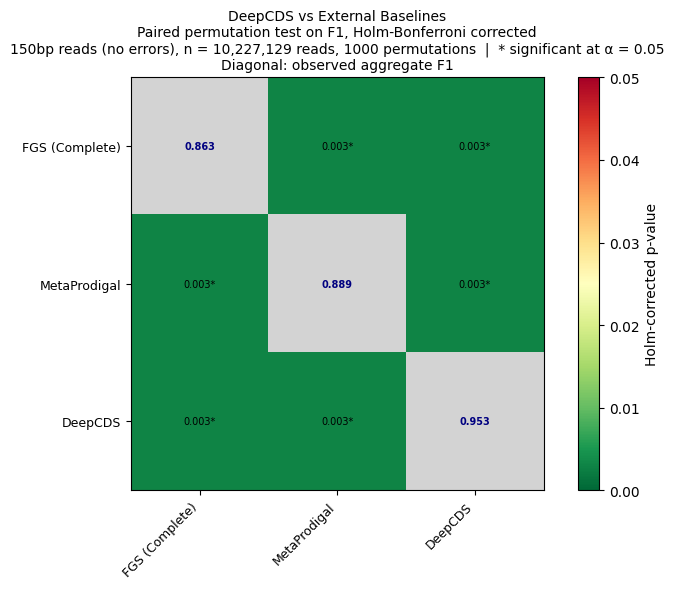

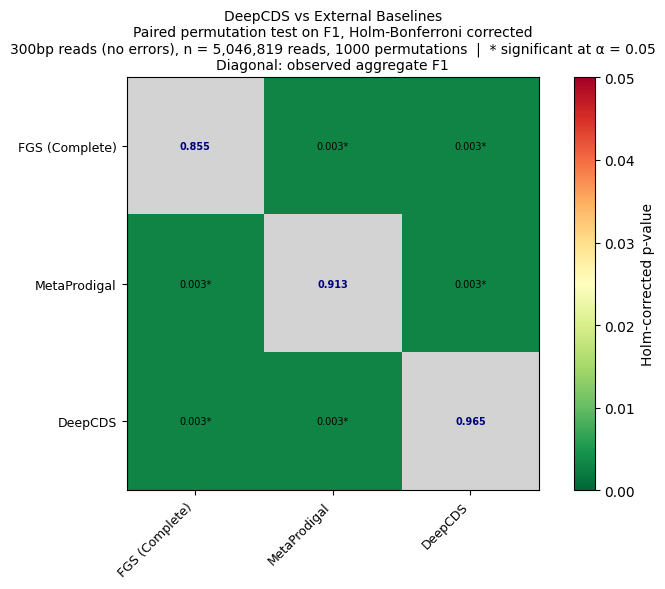

COMPARISON 2: DeepCDS ablation models


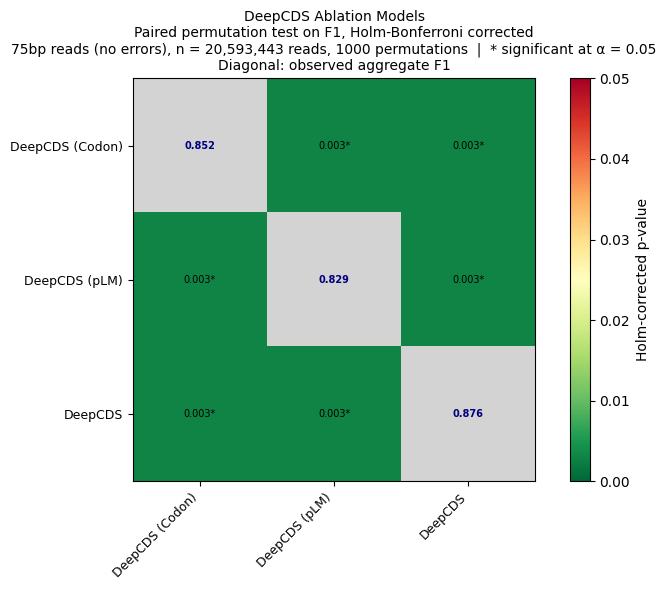

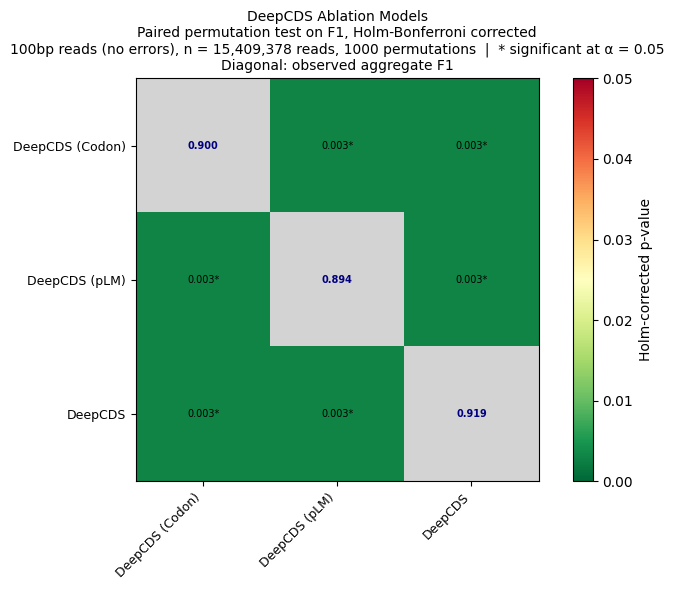

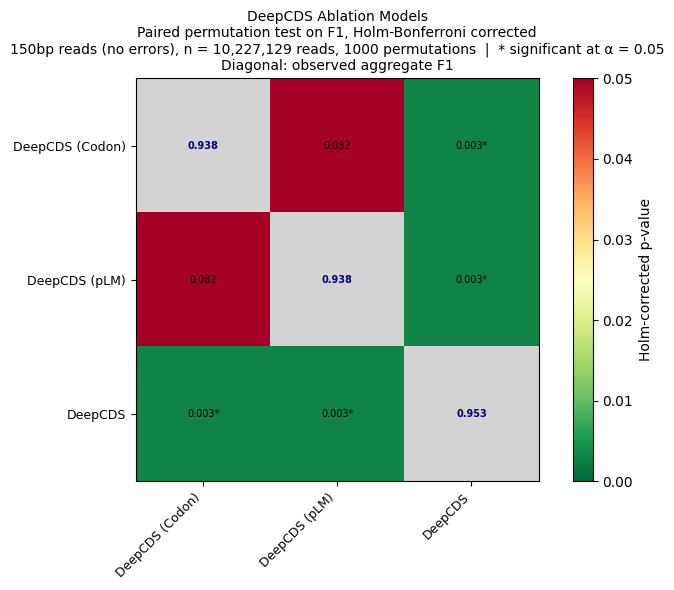

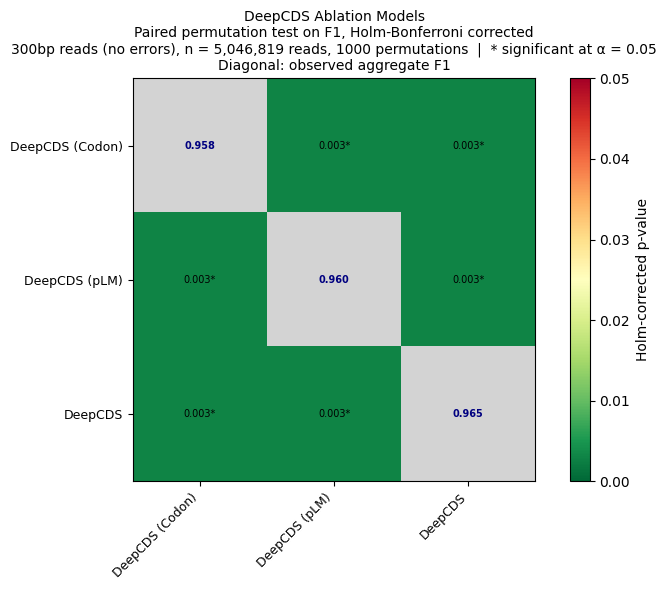

In [23]:
def plot_p_heatmap(p_matrix, models, f1_obs, length, n_reads, title_prefix, alpha=0.05):
    display = [MODEL_DISPLAY_NAMES.get(m, m) for m in models]
    n = len(models)

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = matplotlib.cm.RdYlGn_r.copy()
    cmap.set_bad('lightgray')

    im = ax.imshow(np.ma.masked_invalid(p_matrix), cmap=cmap, vmin=0, vmax=alpha)

    for i in range(n):
        for j in range(n):
            if i == j or np.isnan(p_matrix[i, j]):
                continue
            p = p_matrix[i, j]
            label = (f'<{1.0/N_PERMUTATIONS:.3f}' if p <= 1.0/N_PERMUTATIONS
                     else f'{p:.3f}') + ('*' if p < alpha else '')
            ax.text(j, i, label, ha='center', va='center', fontsize=7)

    for i in range(n):
        if not np.isnan(f1_obs[i]):
            ax.text(i, i, f'{f1_obs[i]:.3f}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='navy')

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(display, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(display, fontsize=9)
    plt.colorbar(im, ax=ax, label='Holm-corrected p-value')
    ax.set_title(
        f'{title_prefix}\n'
        f'Paired permutation test on F1, Holm-Bonferroni corrected\n'
        f'{length}bp reads (no errors), n = {n_reads:,} reads, {N_PERMUTATIONS} permutations'
        f'  |  * significant at α = {alpha}\n'
        f'Diagonal: observed aggregate F1',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


# --- Comparison 1 heatmaps ---
print('COMPARISON 1: DeepCDS vs external baselines')
for length in read_lengths:
    res = permutation_results_baseline[length]
    anchor = res['models'][0]
    n_reads = sum(
        per_read_counts[length][acc][anchor].shape[0]
        for acc in per_read_counts[length]
        if anchor in per_read_counts[length][acc]
    )
    plot_p_heatmap(
        res['p_matrix'], res['models'], res['f1_obs'],
        length, n_reads,
        title_prefix='DeepCDS vs External Baselines'
    )

# --- Comparison 2 heatmaps ---
print('COMPARISON 2: DeepCDS ablation models')
for length in read_lengths:
    res = permutation_results_ablation[length]
    anchor = res['models'][0]
    n_reads = sum(
        per_read_counts[length][acc][anchor].shape[0]
        for acc in per_read_counts[length]
        if anchor in per_read_counts[length][acc]
    )
    plot_p_heatmap(
        res['p_matrix'], res['models'], res['f1_obs'],
        length, n_reads,
        title_prefix='DeepCDS Ablation Models'
    )

In [24]:
def build_summary_table(key_pairs, results_by_length):
    rows = []
    for m1, m2 in key_pairs:
        row = {
            'Model A': MODEL_DISPLAY_NAMES.get(m1, m1),
            'Model B': MODEL_DISPLAY_NAMES.get(m2, m2),
        }
        for length in read_lengths:
            res = results_by_length[length]
            models = res['models']
            if m1 in models and m2 in models:
                i, j = models.index(m1), models.index(m2)
                p = res['p_matrix'][i, j]
                if np.isnan(p):
                    row[f'{length}bp'] = 'N/A'
                elif p <= 1.0 / N_PERMUTATIONS:
                    row[f'{length}bp'] = f'<{1.0/N_PERMUTATIONS:.3f}'
                else:
                    row[f'{length}bp'] = f'{p:.3f}'
            else:
                row[f'{length}bp'] = 'N/A'
        rows.append(row)
    return pd.DataFrame(rows)


# --- Comparison 1 summary ---
baseline_pairs = [
    ('deep_cds', 'fgs_complete'),
    ('deep_cds', 'prodigal'),
    ('fgs_complete', 'prodigal'),
]
print(f'COMPARISON 1: DeepCDS vs external baselines')
print(f'Holm-corrected permutation p-values ({N_PERMUTATIONS} permutations)')
print(build_summary_table(baseline_pairs, permutation_results_baseline).to_string(index=False))

# --- Comparison 2 summary ---
ablation_pairs = [
    ('deep_cds',    'deep_cds_a1'),
    ('deep_cds',    'deep_cds_a2'),
    ('deep_cds_a1', 'deep_cds_a2'),
]
print(f'\nCOMPARISON 2: DeepCDS ablation models')
print(f'Holm-corrected permutation p-values ({N_PERMUTATIONS} permutations)')
print(build_summary_table(ablation_pairs, permutation_results_ablation).to_string(index=False))

COMPARISON 1: DeepCDS vs external baselines
Holm-corrected permutation p-values (1000 permutations)
       Model A        Model B  75bp 100bp 150bp 300bp
       DeepCDS FGS (Complete) 0.003 0.003 0.003 0.003
       DeepCDS   MetaProdigal 0.003 0.003 0.003 0.003
FGS (Complete)   MetaProdigal 0.003 0.003 0.003 0.003

COMPARISON 2: DeepCDS ablation models
Holm-corrected permutation p-values (1000 permutations)
      Model A         Model B  75bp 100bp 150bp 300bp
      DeepCDS   DeepCDS (pLM) 0.003 0.003 0.003 0.003
      DeepCDS DeepCDS (Codon) 0.003 0.003 0.003 0.003
DeepCDS (pLM) DeepCDS (Codon) 0.003 0.003 0.082 0.003
